2D PIELM: Solving w(x, E) where E ∈ [0.9, 1.1]
Collocation grid: 30×10 = 300 points
x range: [0, 2.0]
E range: [0.9, 1.1]

Boundary conditions: 20 constraints
Training time: 0.0658 s

Relative error: 1.86e-02


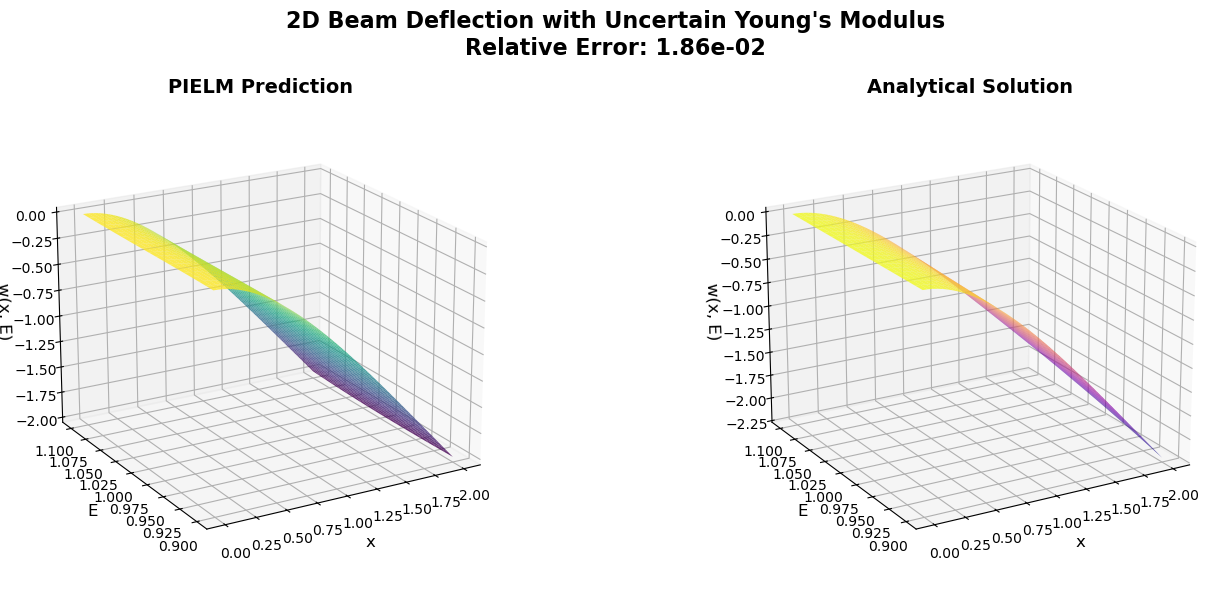


KEY RESULTS

Deflection at free end (x = L):
E		PIELM w(L)	Exact w(L)	Error
--------------------------------------------------
0.900		-2.000717	-2.222222	0.221506
0.950		-2.008024	-2.105263	0.097239
1.000		-2.008865	-2.000000	0.008865
1.050		-2.001231	-1.904762	0.096469
1.100		-1.982023	-1.818182	0.163841

Maximum deflection (across all x, E):
  PIELM: -2.009173
  Exact: -2.222222

Mean absolute error: 0.041412
Max absolute error: 0.221506


In [1]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)
print ("Weights = ", W)
print ("bais =", b)

def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Boundary points (for x=0 and x=L, with E varying)
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x=0) for various E
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x=L) for various E  
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)

print("=" * 60)
print("2D PIELM: Solving w(x, E) where E ∈ [0.9, 1.1]")
print("=" * 60)
print(f"Collocation grid: {n_x}×{n_E} = {n_x*n_E} points")
print(f"x range: [0, {L}]")
print(f"E range: [{E_range[0]}, {E_range[1]}]")

# =============================================================================
# BUILD PDE MATRIX A (for 2D problem)
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_2d(xe_c)  # Shape: (n_x*n_E, hidden_size)
A_cols = []

for j in range(hidden_size):
    wj = H_c[:, j:j+1]
    
    # Compute ∂⁴w/∂x⁴ (derivative with respect to x only)
    # Compute gradient w.r.t BOTH x and E
    grad1 = autograd.grad(wj.sum(), xe_c, create_graph=True)[0]
    # grad1 contains [∂w/∂x, ∂w/∂E]
    
    # Get ∂w/∂x
    dw_dx = grad1[:, 0:1]
    
    # Compute second derivative
    grad2 = autograd.grad(dw_dx.sum(), xe_c, create_graph=True)[0]
    d2w_dx2 = grad2[:, 0:1]
    
    # Compute third derivative
    grad3 = autograd.grad(d2w_dx2.sum(), xe_c, create_graph=True)[0]
    d3w_dx3 = grad3[:, 0:1]
    
    # Compute fourth derivative
    grad4 = autograd.grad(d3w_dx3.sum(), xe_c, create_graph=True)[0]
    d4w_dx4 = grad4[:, 0:1]
    
    A_cols.append(d4w_dx4)

A = I * torch.hstack(A_cols)  # Shape: (n_x*n_E, hidden_size)
b_pde = Q * torch.ones(n_x * n_E, 1)

# =============================================================================
# BOUNDARY CONDITIONS (for each E value)
# =============================================================================
def bc_row_2d(xe_points, order):
    """Compute boundary condition row for 2D input"""
    H = hidden_layer_2d(xe_points)
    row = []
    
    for j in range(hidden_size):
        w = H[:, j:j+1]
        
        if order == 0:
            # w(x, E) value
            row.append(w)
        else:
            # Compute derivative of order 'order' w.r.t x
            current = w
            for _ in range(order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]  # Take ∂/∂x only
            row.append(current)
    
    return torch.hstack(row)

# Boundary condition rows
C_rows = []

# w(0, E) = 0 for all E
C_rows.append(bc_row_2d(xe_0, 0))

# w'(0, E) = 0 for all E (∂w/∂x at x=0)
C_rows.append(bc_row_2d(xe_0, 1))

# w''(L, E) = 0 for all E (∂²w/∂x² at x=L)
C_rows.append(bc_row_2d(xe_L, 2))

# w'''(L, E) = 0 for all E (∂³w/∂x³ at x=L)
C_rows.append(bc_row_2d(xe_L, 3))

C = torch.vstack(C_rows)  # Shape: (4*n_E_bc, hidden_size)
d = torch.zeros(4 * n_E_bc, 1)

print(f"\nBoundary conditions: {C.shape[0]} constraints")

# =============================================================================
# KKT SYSTEM
# =============================================================================
A_T = A.T
C_T = C.T

KKT = torch.zeros(hidden_size + C.shape[0], hidden_size + C.shape[0])
KKT[:hidden_size, :hidden_size] = A_T @ A
KKT[:hidden_size, hidden_size:] = C_T
KKT[hidden_size:, :hidden_size] = C

rhs = torch.vstack([A_T @ b_pde, d])

# Regularization
alpha = 1e-8 * torch.trace(A_T @ A) / hidden_size
KKT += alpha * torch.eye(hidden_size + C.shape[0])

# Solve
solution = torch.linalg.solve(KKT, rhs)
beta = solution[:hidden_size]

print(f"Training time: {default_timer() - t0:.4f} s")

# =============================================================================
# PREDICTION ON 2D GRID
# =============================================================================
# Create prediction grid
n_pred_x = 50
n_pred_E = 20

x_pred_grid = torch.linspace(0, L, n_pred_x)
E_pred_grid = torch.linspace(E_range[0], E_range[1], n_pred_E)
X_pred, E_pred = torch.meshgrid(x_pred_grid, E_pred_grid, indexing='ij')

# Flatten for prediction
X_pred_flat = X_pred.flatten().reshape(-1, 1)
E_pred_flat = E_pred.flatten().reshape(-1, 1)
xe_pred = torch.cat([X_pred_flat, E_pred_flat], dim=1)

# Predict
H_pred = hidden_layer_2d(xe_pred)
w_pred_flat = H_pred @ beta
w_pred = w_pred_flat.reshape(n_pred_x, n_pred_E)

# Analytical solution on same grid
w_exact = analytical_solution(X_pred, E_pred)

# Compute error
error = torch.abs(w_pred - w_exact)
rel_error = torch.mean(error) / torch.max(torch.abs(w_exact))

print(f"\nRelative error: {rel_error.item():.2e}")

# =============================================================================
# SINGLE 3D PLOT (PIELM vs Analytical)
# =============================================================================
fig = plt.figure(figsize=(15, 6))

# Plot 1: PIELM Prediction
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X_pred.detach().numpy(), 
                        E_pred.detach().numpy(), 
                        w_pred.detach().numpy(),
                        cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('E', fontsize=12)
ax1.set_zlabel('w(x, E)', fontsize=12)
ax1.set_title('PIELM Prediction', fontsize=14, fontweight='bold')
ax1.view_init(elev=20, azim=-120)

# Plot 2: Analytical Solution
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_pred.detach().numpy(),
                        E_pred.detach().numpy(),
                        w_exact.detach().numpy(),
                        cmap='plasma', alpha=0.8, edgecolor='none')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('E', fontsize=12)
ax2.set_zlabel('w(x, E)', fontsize=12)
ax2.set_title('Analytical Solution', fontsize=14, fontweight='bold')
ax2.view_init(elev=20, azim=-120)

plt.suptitle(f'2D Beam Deflection with Uncertain Young\'s Modulus\nRelative Error: {rel_error.item():.2e}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# PRINT KEY RESULTS
# =============================================================================
print("\n" + "=" * 60)
print("KEY RESULTS")
print("=" * 60)

# Deflection at free end (x = L) for different E
print("\nDeflection at free end (x = L):")
print("E\t\tPIELM w(L)\tExact w(L)\tError")
print("-" * 50)

E_test = torch.linspace(E_range[0], E_range[1], 5)
for E_val in E_test:
    # Find index in prediction grid
    E_idx = torch.argmin(torch.abs(E_pred_grid - E_val))
    
    # Get deflection at x = L for this E
    L_idx = torch.argmin(torch.abs(x_pred_grid - L))
    w_pielm = w_pred[L_idx, E_idx].item()
    w_exact_val = analytical_solution(torch.tensor([[L]]), torch.tensor([[E_val]])).item()
    
    print(f"{E_val:.3f}\t\t{w_pielm:.6f}\t{w_exact_val:.6f}\t{abs(w_pielm - w_exact_val):.6f}")

# Statistics
print(f"\nMaximum deflection (across all x, E):")
print(f"  PIELM: {torch.min(w_pred).item():.6f}")  # Negative Q gives negative deflection
print(f"  Exact: {torch.min(w_exact).item():.6f}")

print(f"\nMean absolute error: {torch.mean(error).item():.6f}")
print(f"Max absolute error: {torch.max(error).item():.6f}")

In [2]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)
print ("Weights = ", W)
print ("bais =", b)

Weights =  tensor([[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e+00,  6.7842e-01,
         -1.2345e+00, -4.3067e-02, -1.6047e+00, -7.5214e-01,  1.6487e+00,
         -3.9248e-01, -1.4036e+00, -7.2788e-01, -5.5943e-01, -7.6884e-01,
          7.6245e-01,  1.6423e+00, -1.5960e-01, -4.9740e-01,  4.3959e-01,
         -7.5813e-01,  1.0783e+00,  8.0080e-01,  1.6806e+00,  1.2791e+00,
          1.2964e+00,  6.1047e-01,  1.3347e+00, -2.3162e-01,  4.1759e-02,
         -2.5158e-01,  8.5986e-01, -1.3847e+00, -8.7124e-01, -2.2337e-01,
          1.7174e+00,  3.1888e-01, -4.2452e-01,  3.0572e-01, -7.7459e-01,
         -1.5576e+00,  9.9564e-01, -8.7979e-01, -6.0114e-01, -1.2742e+00,
          2.1228e+00, -1.2347e+00, -4.8791e-01, -9.1382e-01, -6.5814e-01],
        [ 7.8024e-02,  5.2581e-01, -4.8799e-01,  1.1914e+00, -8.1401e-01,
         -7.3599e-01, -1.4032e+00,  3.6004e-02, -6.3477e-02,  6.7561e-01,
         -9.7807e-02,  1.8446e+00, -1.1845e+00,  1.3835e+00,  1.4451e+00,
          8.5641e-01,  2.2

In [4]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)


def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)
print ( "x_grid = ", x_grid )
print ( "E_grid = ", E_grid)
# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')
print ( "X,E =", X, E)


# Two separate 1D arrays
#x_points = torch.tensor([0.0, 1.0, 2.0])    # 3 points: [0, 1, 2]
#E_points = torch.tensor([0.9, 1.0, 1.1])    # 3 points: [0.9, 1.0, 1.1]

# Create meshgrid
#X, E = torch.meshgrid(x_points, E_points, indexing='ij')
#X (positions):
#[[0.0, 0.0, 0.0],   # x=0 for all E values
#[1.0, 1.0, 1.0],   # x=1 for all E values
#[2.0, 2.0, 2.0]]   # x=2 for all E values

#E (Young's modulus):
#[[0.9, 1.0, 1.1],   # For x=0: E=0.9, 1.0, 1.1
#[0.9, 1.0, 1.1],   # For x=1: E=0.9, 1.0, 1.1  
#[0.9, 1.0, 1.1]]   # For x=2: E=0.9, 1.0, 1.1

x_grid =  tensor([0.0000, 0.0690, 0.1379, 0.2069, 0.2759, 0.3448, 0.4138, 0.4828, 0.5517,
        0.6207, 0.6897, 0.7586, 0.8276, 0.8966, 0.9655, 1.0345, 1.1034, 1.1724,
        1.2414, 1.3103, 1.3793, 1.4483, 1.5172, 1.5862, 1.6552, 1.7241, 1.7931,
        1.8621, 1.9310, 2.0000])
E_grid =  tensor([0.9000, 0.9222, 0.9444, 0.9667, 0.9889, 1.0111, 1.0333, 1.0556, 1.0778,
        1.1000])
X,E = tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0690, 0.0690, 0.0690, 0.0690, 0.0690, 0.0690, 0.0690, 0.0690, 0.0690,
         0.0690],
        [0.1379, 0.1379, 0.1379, 0.1379, 0.1379, 0.1379, 0.1379, 0.1379, 0.1379,
         0.1379],
        [0.2069, 0.2069, 0.2069, 0.2069, 0.2069, 0.2069, 0.2069, 0.2069, 0.2069,
         0.2069],
        [0.2759, 0.2759, 0.2759, 0.2759, 0.2759, 0.2759, 0.2759, 0.2759, 0.2759,
         0.2759],
        [0.3448, 0.3448, 0.3448, 0.3448, 0.3448, 0.3448, 0.3448, 0.3448, 0.3448,
         0.3448],
        [0

In [5]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)


def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')
# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)
print ("X_flat = ", X_flat)
print ("E_flat = ", E_flat)


X_flat =  tensor([[0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.0690],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.1379],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2069],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.2759],
        [0.3448],
        [0.3448],
        [0.3448],
        [0.3448],
        [0.3448],


In [6]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)


def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')
# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)
print ("xe_c = ",xe_c)


xe_c =  tensor([[0.0000, 0.9000],
        [0.0000, 0.9222],
        [0.0000, 0.9444],
        [0.0000, 0.9667],
        [0.0000, 0.9889],
        [0.0000, 1.0111],
        [0.0000, 1.0333],
        [0.0000, 1.0556],
        [0.0000, 1.0778],
        [0.0000, 1.1000],
        [0.0690, 0.9000],
        [0.0690, 0.9222],
        [0.0690, 0.9444],
        [0.0690, 0.9667],
        [0.0690, 0.9889],
        [0.0690, 1.0111],
        [0.0690, 1.0333],
        [0.0690, 1.0556],
        [0.0690, 1.0778],
        [0.0690, 1.1000],
        [0.1379, 0.9000],
        [0.1379, 0.9222],
        [0.1379, 0.9444],
        [0.1379, 0.9667],
        [0.1379, 0.9889],
        [0.1379, 1.0111],
        [0.1379, 1.0333],
        [0.1379, 1.0556],
        [0.1379, 1.0778],
        [0.1379, 1.1000],
        [0.2069, 0.9000],
        [0.2069, 0.9222],
        [0.2069, 0.9444],
        [0.2069, 0.9667],
        [0.2069, 0.9889],
        [0.2069, 1.0111],
        [0.2069, 1.0333],
        [0.2069, 1.0556],
    

In [8]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)

def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Boundary points (for x=0 and x=L, with E varying)
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)
print ("E_bc = ", E_bc)

# Left boundary (x=0) for various E
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)
print ("xe_0 = ",xe_0)

# Right boundary (x=L) for various E  
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)
print("xe_L = ",xe_L)


E_bc =  tensor([[0.9000],
        [0.9500],
        [1.0000],
        [1.0500],
        [1.1000]])
xe_0 =  tensor([[0.0000, 0.9000],
        [0.0000, 0.9500],
        [0.0000, 1.0000],
        [0.0000, 1.0500],
        [0.0000, 1.1000]], requires_grad=True)
xe_L =  tensor([[2.0000, 0.9000],
        [2.0000, 0.9500],
        [2.0000, 1.0000],
        [2.0000, 1.0500],
        [2.0000, 1.1000]], requires_grad=True)


In [10]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)

def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Boundary points (for x=0 and x=L, with E varying)
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x=0) for various E
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x=L) for various E  
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)
# =============================================================================
# BUILD PDE MATRIX A (for 2D problem)
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_2d(xe_c)  # Shape: (n_x*n_E, hidden_size)
# xe_input = torch.tensor([
#    [0.0, 0.9],   # Point 1: x=0, E=0.9
#   [1.0, 1.0],   # Point 2: x=1, E=1.0
#   [1.5, 1.05],  # Point 3: x=1.5, E=1.05
#   [2.0, 1.1]    # Point 4: x=2, E=1.1
# Shape: (4, 2)
#H_c = torch.tanh(xe_input @ W + b)  # (4,2) @ (2,3) + (3,) = (4,3)
A_cols = []
print ("H_c =", H_c)
for j in range(hidden_size):
    wj = H_c[:, j:j+1]
    print ("wj =",wj)    
    # Compute ∂⁴w/∂x⁴ (derivative with respect to x only)
    # Compute gradient w.r.t BOTH x and E
    grad1 = autograd.grad(wj.sum(), xe_c, create_graph=True)[0]
    # grad1 contains [∂w/∂x, ∂w/∂E]
    
    # Get ∂w/∂x
    dw_dx = grad1[:, 0:1]
    
    # Compute second derivative
    grad2 = autograd.grad(dw_dx.sum(), xe_c, create_graph=True)[0]
    d2w_dx2 = grad2[:, 0:1]
    
    # Compute third derivative
    grad3 = autograd.grad(d2w_dx2.sum(), xe_c, create_graph=True)[0]
    d3w_dx3 = grad3[:, 0:1]
    
    # Compute fourth derivative
    grad4 = autograd.grad(d3w_dx3.sum(), xe_c, create_graph=True)[0]
    d4w_dx4 = grad4[:, 0:1]
    
    A_cols.append(d4w_dx4)

A = I * torch.hstack(A_cols)  # Shape: (n_x*n_E, hidden_size)
print ("A =", A)
b_pde = Q * torch.ones(n_x * n_E, 1)
print ("b_pde =" ,b_pde)
#H_c = [[0.58, -0.43, 0.66],   # Point 0: 3 neurons' activations
#       [0.86, -0.22, 0.77]]   # Point 1: 3 neurons' activations
# w0 = [[0.58], [0.86]] ← Neuron 0's activations at both points
# w1 = [[-0.43], [-0.22]] ← Neuron 1's activations at both points
# w2 = [[0.66], [0.77]]



H_c = tensor([[ 0.6620,  0.5112, -0.6795,  ...,  0.3086, -0.6878, -0.3869],
        [ 0.6630,  0.5198, -0.6853,  ...,  0.3111, -0.6836, -0.3751],
        [ 0.6640,  0.5283, -0.6910,  ...,  0.3135, -0.6795, -0.3633],
        ...,
        [ 0.9998,  0.9986,  0.7150,  ..., -0.5633, -0.9894, -0.9258],
        [ 0.9998,  0.9986,  0.7096,  ..., -0.5614, -0.9892, -0.9238],
        [ 0.9998,  0.9986,  0.7042,  ..., -0.5596, -0.9891, -0.9218]],
       grad_fn=<TanhBackward0>)
wj = tensor([[0.6620],
        [0.6630],
        [0.6640],
        [0.6649],
        [0.6659],
        [0.6669],
        [0.6678],
        [0.6688],
        [0.6697],
        [0.6707],
        [0.7303],
        [0.7311],
        [0.7319],
        [0.7327],
        [0.7335],
        [0.7343],
        [0.7351],
        [0.7359],
        [0.7367],
        [0.7375],
        [0.7865],
        [0.7872],
        [0.7878],
        [0.7885],
        [0.7891],
        [0.7898],
        [0.7904],
        [0.7911],
        [0.7917],
 

In [12]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP (inputs: x AND E)
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)

def hidden_layer_2d(xe):
    """Hidden layer for 2D input [x, E]"""
    return torch.tanh(xe @ W + b)

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 30   # Points in x direction
n_E = 10   # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Boundary points (for x=0 and x=L, with E varying)
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x=0) for various E
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x=L) for various E  
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)

# BUILD PDE MATRIX A (for 2D problem)
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_2d(xe_c)  # Shape: (n_x*n_E, hidden_size)
A_cols = []

for j in range(hidden_size):
    wj = H_c[:, j:j+1]
    
    # Compute ∂⁴w/∂x⁴ (derivative with respect to x only)
    # Compute gradient w.r.t BOTH x and E
    grad1 = autograd.grad(wj.sum(), xe_c, create_graph=True)[0]
    # grad1 contains [∂w/∂x, ∂w/∂E]
    
    # Get ∂w/∂x
    dw_dx = grad1[:, 0:1]
    
    # Compute second derivative
    grad2 = autograd.grad(dw_dx.sum(), xe_c, create_graph=True)[0]
    d2w_dx2 = grad2[:, 0:1]
    
    # Compute third derivative
    grad3 = autograd.grad(d2w_dx2.sum(), xe_c, create_graph=True)[0]
    d3w_dx3 = grad3[:, 0:1]
    
    # Compute fourth derivative
    grad4 = autograd.grad(d3w_dx3.sum(), xe_c, create_graph=True)[0]
    d4w_dx4 = grad4[:, 0:1]
    
    A_cols.append(d4w_dx4)

A = I * torch.hstack(A_cols)  # Shape: (n_x*n_E, hidden_size)
b_pde = Q * torch.ones(n_x * n_E, 1)

# =============================================================================
# BOUNDARY CONDITIONS (for each E value)
# =============================================================================
def bc_row_2d(xe_points, order):
    """Compute boundary condition row for 2D input"""
    H = hidden_layer_2d(xe_points)
    row = []
    
    for j in range(hidden_size):
        w = H[:, j:j+1]
        
        if order == 0:
            # w(x, E) value
            row.append(w)
        else:
            # Compute derivative of order 'order' w.r.t x
            current = w
            for _ in range(order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]  # Take ∂/∂x only
            row.append(current)
    
    return torch.hstack(row)

# Boundary condition rows
C_rows = []

# w(0, E) = 0 for all E
C_rows.append(bc_row_2d(xe_0, 0))
# w'(0, E) = 0 for all E (∂w/∂x at x=0)
C_rows.append(bc_row_2d(xe_0, 1))

# w''(L, E) = 0 for all E (∂²w/∂x² at x=L)
C_rows.append(bc_row_2d(xe_L, 2))

# w'''(L, E) = 0 for all E (∂³w/∂x³ at x=L)
C_rows.append(bc_row_2d(xe_L, 3))

C = torch.vstack(C_rows)  # Shape: (4*n_E_bc, hidden_size)
d = torch.zeros(4 * n_E_bc, 1)
print ("C = ",C)
print ("d = ",d)

print(f"\nBoundary conditions: {C.shape[0]} constraints")


C =  tensor([[ 6.6202e-01,  5.1122e-01, -6.7954e-01,  9.2169e-01,  2.8993e-01,
         -8.7804e-01, -2.4471e-01, -2.8986e-01,  7.7705e-01,  7.3885e-01,
          5.5939e-01,  9.6875e-01, -9.2739e-01,  9.4161e-01,  6.7800e-01,
          2.7174e-01,  9.5270e-01,  9.7081e-01,  7.4726e-01,  3.7858e-01,
         -8.6429e-01,  7.9673e-01, -8.1536e-02,  8.5914e-01, -3.1347e-01,
          8.8892e-01, -1.6755e-01,  5.9193e-02, -9.4341e-01, -6.1838e-01,
         -8.9038e-01, -7.0208e-01, -7.3390e-01, -6.2746e-01,  6.3604e-01,
         -5.1463e-01,  9.5821e-01, -6.1360e-01, -3.9654e-02,  9.2674e-01,
         -8.0985e-01, -2.6510e-01,  7.6739e-01,  9.9649e-01,  7.5308e-01,
         -7.2274e-01, -8.8065e-01,  3.0859e-01, -6.8776e-01, -3.8687e-01],
        [ 6.6420e-01,  5.3038e-01, -6.9246e-01,  9.3018e-01,  2.5222e-01,
         -8.8620e-01, -3.0945e-01, -2.8821e-01,  7.7579e-01,  7.5381e-01,
          5.5602e-01,  9.7394e-01, -9.3524e-01,  9.4896e-01,  7.1516e-01,
          3.1092e-01,  9.6193e-0